In [2]:
!pip install IProgress

In [1]:
import pandas as pd
from transformers import GPT2Tokenizer
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import stats
from sklearn.model_selection import train_test_split

/Users/anrilombard/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_csv("nguni_languages_dataset.csv")

In [5]:
# df.shape
df["language"].value_counts()

language
isiZulu       116693
isiXhosa       99567
isiNdebele      1260
Name: count, dtype: int64

In [6]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2", clean_up_tokenization_spaces=True)
tokenizer.model_max_length = float("inf")


def count_tokens(text):
    tokens = tokenizer.encode(text)
    return len(tokens)


tqdm.pandas(desc="Tokenizing texts")
df["token_count"] = df["text"].progress_apply(count_tokens)

Tokenizing texts:   0%|          | 812/217520 [00:02<11:20, 318.56it/s]


KeyboardInterrupt: 

In [25]:
stats = (
    df.groupby("language")
    .agg({"text": "count", "token_count": ["mean", "median", "std", "min", "max"]})
    .round(2)
)

stats

text token_count                              
             count        mean  median      std  min     max
language                                                    
isiNdebele    1260      991.88   727.5   812.15  165    6349
isiXhosa     99567     1421.00   996.0  1572.72   89  113710
isiZulu     116693     1650.68  1012.0  2829.01  101  335530

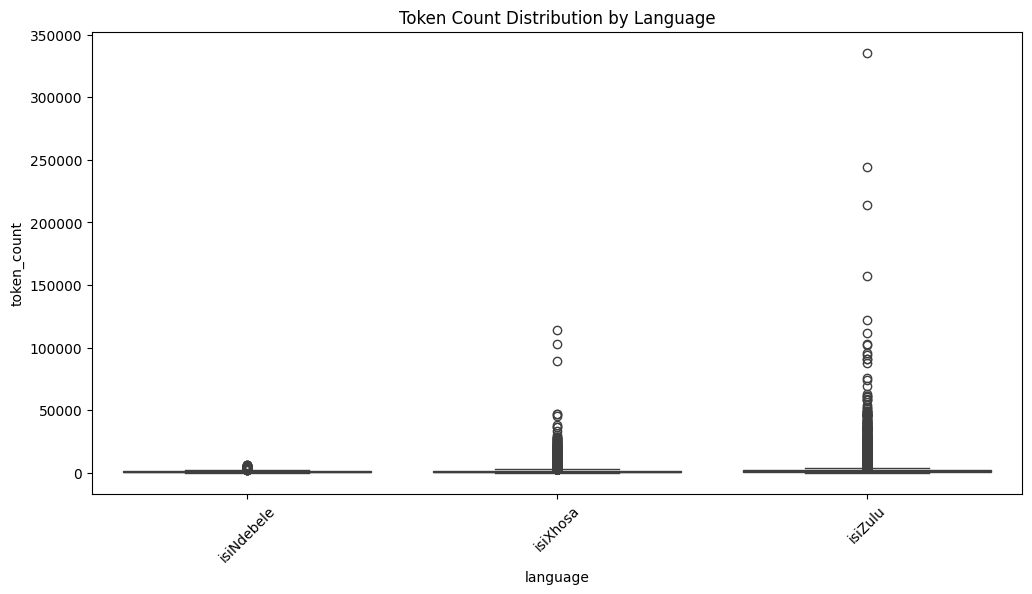

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="language", y="token_count")
plt.title("Token Count Distribution by Language")
# plt.yscale('log')
plt.xticks(rotation=45)
plt.show()

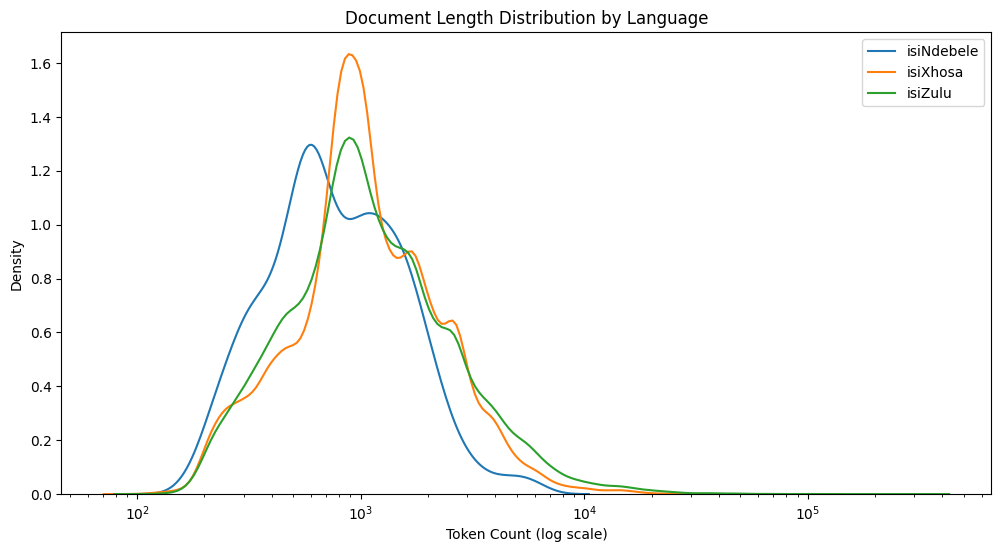

In [27]:
plt.figure(figsize=(12, 6))
for lang in df["language"].unique():
    sns.kdeplot(
        data=df[df["language"] == lang]["token_count"], label=lang, log_scale=True
    )
plt.title("Document Length Distribution by Language")
plt.xlabel("Token Count (log scale)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [28]:
def detect_outliers(df, n_std=3):
    lang_groups = df.groupby("language")
    df["is_outlier"] = False

    for lang, group in lang_groups:
        mean = group["token_count"].mean()
        std = group["token_count"].std()
        outlier_mask = (group["token_count"] > mean + n_std * std) | (
            group["token_count"] < mean - n_std * std
        )
        df.loc[group.index, "is_outlier"] = outlier_mask

    return df


def calculate_type_token_ratio(text):
    tokens = tokenizer.encode(text)
    unique_tokens = len(set(tokens))
    total_tokens = len(tokens)
    return unique_tokens / total_tokens if total_tokens > 0 else 0


df = detect_outliers(df)
df["type_token_ratio"] = df["text"].progress_apply(calculate_type_token_ratio)

Tokenizing texts: 100%|██████████| 217520/217520 [08:17<00:00, 436.90it/s]


In [29]:
def create_length_bins(df, n_bins=5):
    df["length_bin"] = pd.qcut(df["token_count"], n_bins, labels=False)
    return df


df = create_length_bins(df)

In [69]:
def scientific_sampling(df, target_size_per_language=None):
    balanced_dfs = []

    for lang in df["language"].unique():
        lang_df = df[df["language"] == lang].copy()

        # Create 5 strata based on text length
        lang_df["length_strata"] = pd.qcut(lang_df["token_count"], q=5, labels=False)

        if len(lang_df) > target_size_per_language:
            # Downsampling
            samples_per_stratum = target_size_per_language // 5

            sampled = []
            for stratum in range(5):
                stratum_df = lang_df[lang_df["length_strata"] == stratum]
                # Simple random sampling within each stratum
                sampled_stratum = stratum_df.sample(
                    n=min(samples_per_stratum, len(stratum_df)), random_state=42
                )
                sampled.append(sampled_stratum)

            sampled = pd.concat(sampled)

        else:
            # Upsampling (for isiNdebele)
            samples_per_stratum = target_size_per_language // 5

            sampled = []
            for stratum in range(5):
                stratum_df = lang_df[lang_df["length_strata"] == stratum]
                # Preserve all original samples
                if len(stratum_df) > 0:
                    # Add additional samples through random sampling with replacement
                    additional = stratum_df.sample(
                        n=samples_per_stratum - len(stratum_df),
                        replace=True,
                        random_state=42,
                    )
                    sampled.append(pd.concat([stratum_df, additional]))

            sampled = pd.concat(sampled)

        balanced_dfs.append(sampled)

    return pd.concat(balanced_dfs, ignore_index=True)

In [70]:
def validate_balance(df_original, df_balanced):
    metrics = {}

    # Distribution similarity tests
    for lang in df_balanced["language"].unique():
        orig_dist = df_original[df_original["language"] == lang]["token_count"]
        bal_dist = df_balanced[df_balanced["language"] == lang]["token_count"]

        metrics[f"{lang}_ks_test"] = stats.ks_2samp(orig_dist, bal_dist)

    # Vocabulary coverage
    metrics["vocabulary_retention"] = {}
    for lang in df_balanced["language"].unique():
        orig_vocab = set(
            " ".join(df_original[df_original["language"] == lang]["text"]).split()
        )
        bal_vocab = set(
            " ".join(df_balanced[df_balanced["language"] == lang]["text"]).split()
        )
        metrics["vocabulary_retention"][lang] = len(bal_vocab) / len(orig_vocab)

    return metrics

In [76]:
smallest_size = df.groupby("language")["text"].count().min()
target_size = smallest_size * 10

df_balanced = scientific_sampling(df, target_size)
validation_metrics = validate_balance(df, df_balanced)

In [77]:
df_balanced.groupby("language")["text"].count()

print("\nValidation Metrics:")
print("-------------------")
print("\nKS-Test Results (comparing token distributions):")
for lang in validation_metrics:
    if "_ks_test" in lang:
        print(
            f"{lang.replace('_ks_test', '')}: p-value = {validation_metrics[lang].pvalue:.4f}"
        )

print("\nVocabulary Retention:")
for lang, retention in validation_metrics["vocabulary_retention"].items():
    print(f"{lang}: {retention:.2%}")


Validation Metrics:
-------------------

KS-Test Results (comparing token distributions):
isiNdebele: p-value = 1.0000
isiXhosa: p-value = 0.9731
isiZulu: p-value = 0.9659

Vocabulary Retention:
isiNdebele: 100.00%
isiXhosa: 24.07%
isiZulu: 22.32%


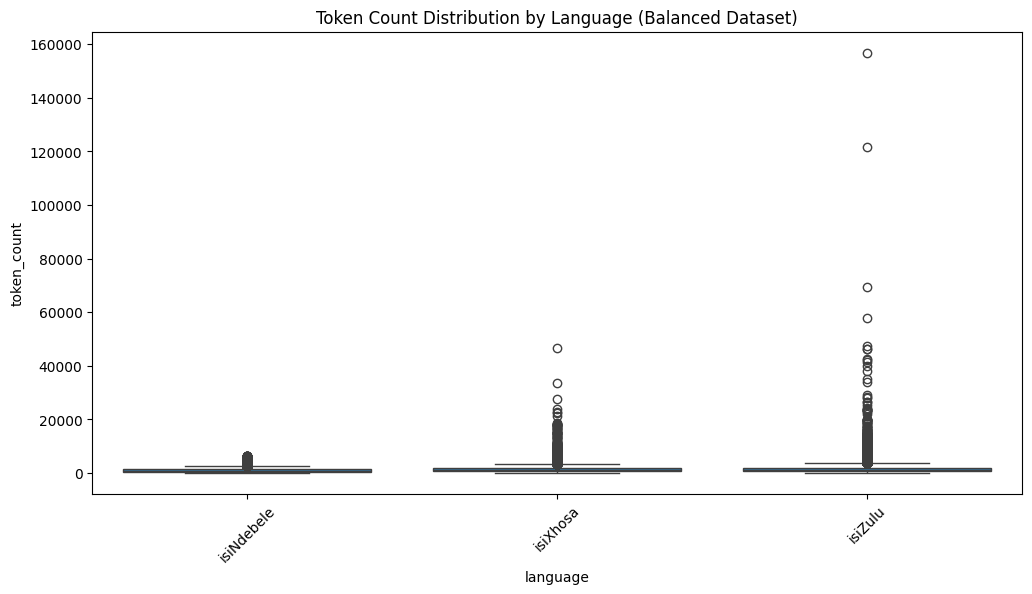

In [78]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_balanced, x="language", y="token_count")
plt.title("Token Count Distribution by Language (Balanced Dataset)")
plt.xticks(rotation=45)
plt.show()

In [88]:
df_balanced.to_csv(
    "balanced_nguni_dataset.csv", index=False, columns=["text", "language"]
)

In [2]:
def create_train_val_split(
    df, val_size=0.2, stratify_col="language", random_state=42, shuffle_data=True
):
    try:
        # Initialize tqdm progress bar
        with tqdm(total=4, desc="Processing") as pbar:
            # Shuffle the dataframe if requested
            if shuffle_data:
                df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
                pbar.update(1)  # Update progress bar after shuffling

            # Perform stratified split
            train_df, val_df = train_test_split(
                df,
                test_size=val_size,
                stratify=df[stratify_col],
                random_state=random_state,
            )
            pbar.update(1)  # Update progress bar after splitting

            # Verify the splits maintain language distribution
            original_dist = df[stratify_col].value_counts(normalize=True)
            train_dist = train_df[stratify_col].value_counts(normalize=True)
            val_dist = val_df[stratify_col].value_counts(normalize=True)

            print("\nData Distribution Verification:")
            print("-" * 30)
            print(f"Original distribution:\n{original_dist}")
            print(f"\nTrain distribution:\n{train_dist}")
            print(f"\nValidation distribution:\n{val_dist}")
            pbar.update(1)  # Update progress bar after verification

            # Save the splits to CSV
            train_df.to_csv("filtered_data_train.csv", index=False)
            val_df.to_csv("filtered_data_val.csv", index=False)

            print("\nFiles saved:")
            print("- filtered_data_train.csv")
            print("- filtered_data_val.csv")
            pbar.update(1)  # Update progress bar after saving files

        return train_df, val_df

    except Exception as e:
        print(f"Error creating train/val split: {str(e)}")
        return None, None


# df_balanced = pd.read_csv("balanced_nguni_dataset.csv")
combined_filtered_data = pd.read_csv("combined_filtered_data.csv")
train_df, val_df = create_train_val_split(combined_filtered_data)
# train_df, val_df = create_train_val_split(df)

KeyboardInterrupt: 